In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd

dpi = 150
mpl.rcParams['figure.dpi'] = dpi
sns.set_theme(context='notebook', style='ticks')

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from matplotlib.colors import ListedColormap, to_rgba
# xr.set_options(engine='h5netcdf')


In [2]:
def cftime_to_decimal_year(times):
    """Convert xarray cftime to decimal years"""
    result = []
    for t in times:
        year = t.year
        start = type(t)(year, 1, 1, calendar=getattr(t, 'calendar', None))
        end = type(t)(year + 1, 1, 1, calendar=getattr(t, 'calendar', None))
        days_in_year = (end - start).days
        day_of_year = (t - start).days + (t - start).seconds / 86400.0
        result.append(year + day_of_year / days_in_year)
    return result

def extend_center_color(cmap, vmin, vmax, center_min=-1, center_max=1, n_colors=256):
    # Get the colormap object if string is provided
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    
    # Get colors from the colormap
    colors = cmap(np.linspace(0, 1, n_colors))
    
    # Calculate the extent of the center region as a fraction of the total range
    total_range = vmax - vmin
    center_range = center_max - center_min
    center_fraction = center_range / total_range
    
    # Find the center index and width of center region
    center_idx = n_colors // 2
    center_half_width = int(n_colors * center_fraction / 2)
    
    # Get the center color
    center_color = colors[center_idx]
    
    # Replace the center region with the center color
    colors[center_idx - center_half_width:center_idx + center_half_width] = center_color
    
    return ListedColormap(colors)


### Load in data

In [3]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x
ds = xr.open_dataset(
        datadir("/model/Southern_Ocean_DSW_1000m_WMT_Budget.zarr"))

ds["BF_Adv"] = ds["surface_ocean_flux_advective_negative_rhs"]
ds["BF_NonAdv"] = ds["boundary_fluxes"] - ds["BF_Adv"]

ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]

ds["boundary_fluxes_heat"] = ds["surface_ocean_flux_advective_negative_rhs_heat"] +\
                                 ds["surface_exchange_flux_heat"] +\
                                 ds["frazil_ice_heat"] + ds["bottom_flux_heat"]

ds["boundary_fluxes_salt"] = ds["surface_ocean_flux_advective_negative_rhs_salt"] +\
                                 ds["surface_exchange_flux_salt"]

ds["surface_boundary_fluxes_salt"] = 1 * ds["boundary_fluxes_salt"]
ds["surface_boundary_fluxes_heat"] = ds["boundary_fluxes_heat"] - ds["bottom_flux_heat"]

expt_colors = dict(); expt_colors["control"] = "#2f74b3"; expt_colors["forced"] = "#cc415a"

In [4]:
toTg = 1e-9 

use_averaging = True 
ds_yearly = ds.fillna(0.0).groupby("time.year").mean("time")
ds_yearly.coords["time_since_init"] = ds.time_since_init.compute().groupby("time.year").mean('time').dt.year

psi40_abyssal = ds_yearly.sel(sigma2_l_target = slice(20, 38.1)).convergent_mass_transport.fillna(0.0)
abyssal_dmdt = ds_yearly.sel(sigma2_l_target = slice(20, 38.1)).mass_tendency.fillna(0.0)
abyssal_sbf = ds_yearly.sel(sigma2_l_target = slice(20, 38.1))["surface_boundary_fluxes"].fillna(0.0)
# ds_sigma = ds_yearly.sel(sigma2_l_target = sigma, method = "nearest")

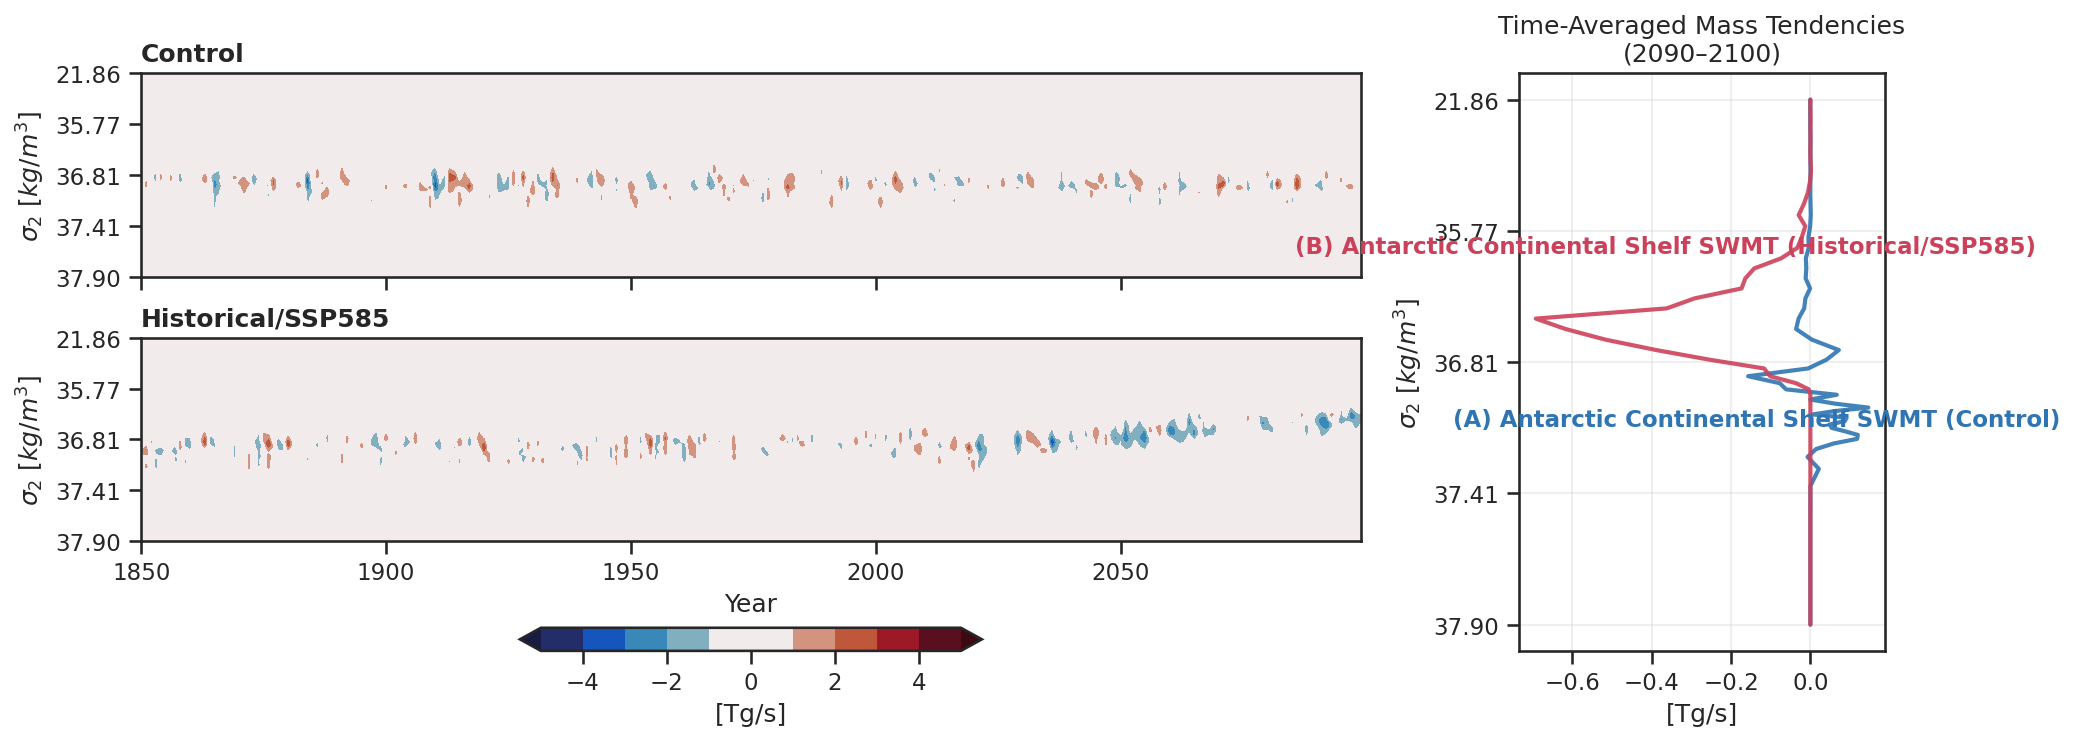

In [5]:
# Create a 2×2 GridSpec where the right column spans both rows
from matplotlib.colors import TwoSlopeNorm

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.3], wspace=0.2, hspace=0.3)

# Left column: two stacked contour plots
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

# Right column: one plot spanning both rows
ax_side = fig.add_subplot(gs[:, 1])

ax = [ax0, ax1, ax_side]
year = psi40_abyssal.year
density =  psi40_abyssal.sigma2_l_target
telescope_power = 10
transformed_density = density_transform(density, telescope_power)

TIME, DENS = np.meshgrid(year, transformed_density)

levels = np.arange(-5, 5 + 0.1, 1.)
vmin = np.min(levels); vmax = np.max(levels)
cmap = extend_center_color(cmo.balance, vmin, vmax, center_min=-1, center_max=1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)


ax[0].contourf(TIME,DENS, 
               toTg * abyssal_dmdt.sel(exp = "control").T, 
               levels = levels, extend = "both", cmap = cmap, norm = norm)

cm = ax[1].contourf(TIME,DENS, 
               toTg * abyssal_dmdt.sel(exp = "forced").T, 
               levels = levels, extend = "both", cmap = cmap, norm = norm)

fig.colorbar(cm, ax = ax[0:2], orientation = "horizontal", fraction = 0.04, label = "[Tg/s]")

ax[0].set_title("Control", loc='left', fontweight = "bold")
ax[1].set_title("Historical/SSP585", loc='left', fontweight = "bold")
ax[0].tick_params(labelbottom=False)
ax[1].set_xlabel("Year")

formatter = create_density_formatter(density, transformed_density)

for a in ax: 
    a.tick_params(bottom=True, left=True)
    a.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
    a.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    a.invert_yaxis()


abyssal_stats = toTg* abyssal_dmdt.astype(np.float64).sel(year = slice(2050, 2100)).quantile([0.05, 0.5, 0.95], dim="year")

control_stats = abyssal_stats.sel(exp = "control");
forced_stats = abyssal_stats.sel(exp = "forced"); 

ax[-1].plot(control_stats.sel(quantile = 0.5), transformed_density, c = expt_colors["control"], alpha = .9, lw = 2)
ax[-1].plot(forced_stats.sel(quantile = 0.5), transformed_density, c = expt_colors["forced"], alpha = .9, lw = 2)

# Use axis coordinates (0 to 1 range)
ax[-1].text(0.65, 0.4, '(A) Antarctic Continental Shelf SWMT (Control)', 
            color=expt_colors["control"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].text(0.4, 0.7, "(B) Antarctic Continental Shelf SWMT (Historical/SSP585)",
            color=expt_colors["forced"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

# fig.suptitle("Antarctic Continental Shelf Mass Tendencies " + r"", x = 0.37)

ax[-1].set_title("Time-Averaged Mass Tendencies\n(2090–2100)")
ax[-1].set_xlabel("[Tg/s]")
ax[-1].grid(alpha = 0.3)

xticks = ax1.get_yticks()
ax_side.set_yticks(xticks);

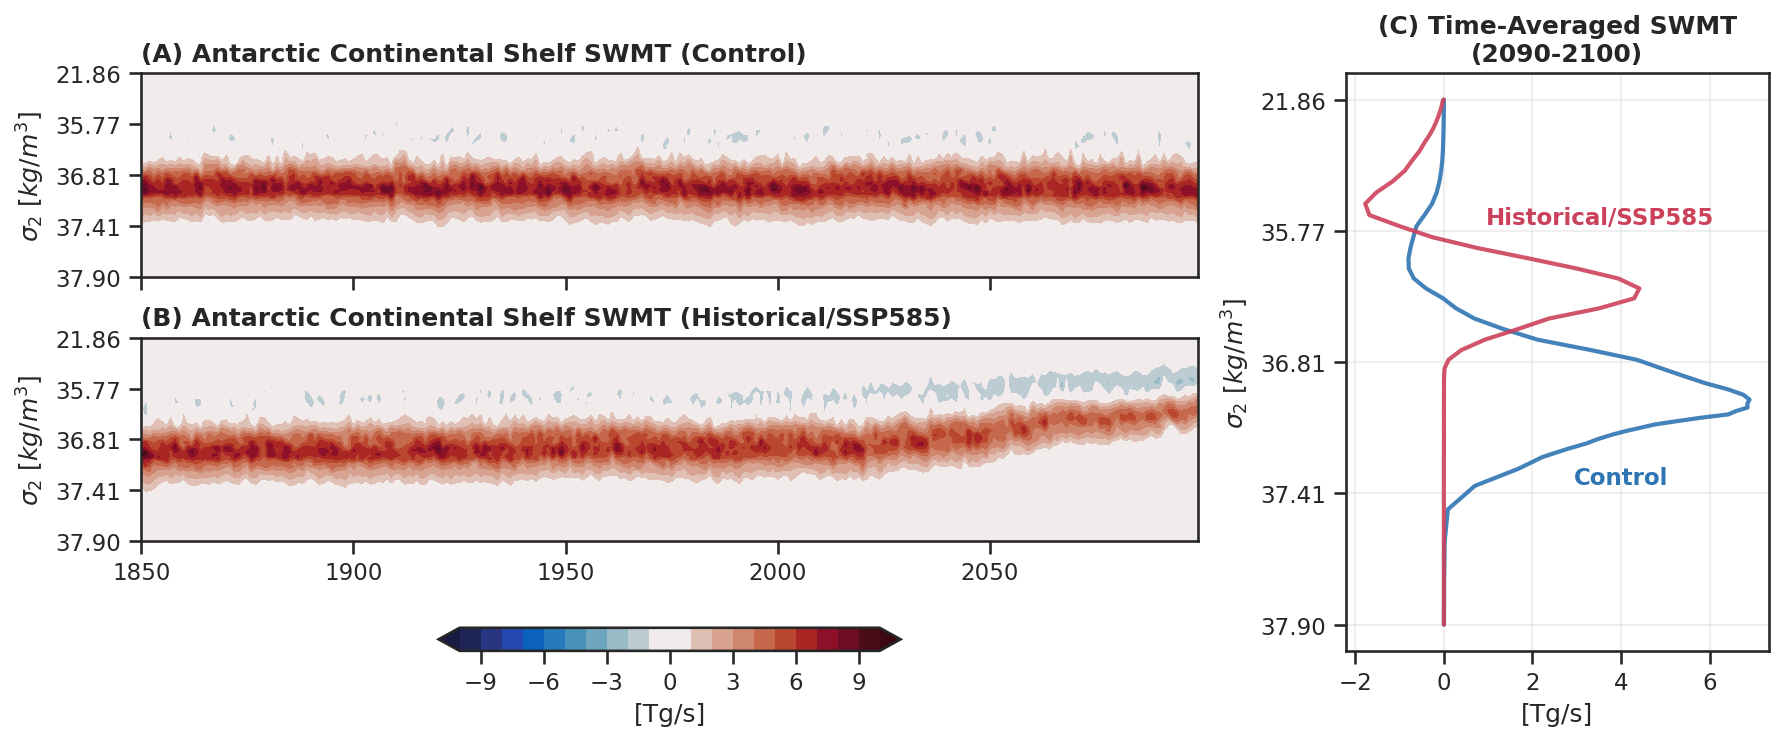

In [6]:
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.4], wspace=0.2, hspace=0.3)

# Left column: two stacked contour plots
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

# Right column: one plot spanning both rows
ax_side = fig.add_subplot(gs[:, 1])

ax = [ax0, ax1, ax_side]
ax[0].tick_params(labelbottom=False)

year = abyssal_sbf.year
density =  abyssal_sbf.sigma2_l_target
telescope_power = 10
transformed_density = density_transform(density, telescope_power)

TIME, DENS = np.meshgrid(year, transformed_density)

levels = np.arange(-10, 10 + 0.01, 1.0)
vmin = np.min(levels); vmax = np.max(levels)
cmap = extend_center_color(cmo.balance, vmin, vmax, center_min=-1, center_max=1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# norm = BoundaryNorm(levels, cmo.balance.N)

cm = ax[0].contourf(TIME,DENS, 
               toTg * abyssal_sbf.sel(exp = "control").T, 
               levels = levels, extend = "both", cmap = cmap, norm = norm)

ax[1].contourf(TIME,DENS, 
               toTg * abyssal_sbf.sel(exp = "forced").T, 
               levels = levels, extend = "both", cmap = cmap)

fig.colorbar(cm, ax = ax[0:2], orientation = "horizontal", fraction = 0.04, label = "[Tg/s]")

# fig.suptitle("", x = 0.37)
ax[0].set_title("(A) Antarctic Continental Shelf SWMT (Control)", loc='left', fontweight = "bold")
ax[1].set_title("(B) Antarctic Continental Shelf SWMT (Historical/SSP585)", loc='left', fontweight = "bold")

formatter = create_density_formatter(density, transformed_density)

for a in ax: 
    a.tick_params(bottom=True, left=True)
    a.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
    a.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    a.invert_yaxis()

abyssal_sbf_mean = abyssal_sbf.sel(year = slice(2090, 2100)).mean("year")
abyssal_sbf_mean = toTg *abyssal_sbf_mean
control_mean = abyssal_sbf_mean.sel(exp = "control"); #control_mean = control_mean.where(np.abs(control_mean) > 1e-8)
forced_mean = abyssal_sbf_mean.sel(exp = "forced"); #forced_mean = forced_mean.where(np.abs(forced_mean) > 1e-8)

ax[-1].plot(control_mean, transformed_density, c = expt_colors["control"], label = "control", alpha = .9, lw = 2)
ax[-1].plot(forced_mean, transformed_density, c = expt_colors["forced"], label = "forced", alpha = .9, lw = 2)
# Use axis coordinates (0 to 1 range)
ax[-1].text(0.65, 0.3, 'Control', 
            color=expt_colors["control"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].text(0.6, 0.75, "Historical/SSP585",
            color=expt_colors["forced"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].set_title("(C) Time-Averaged SWMT\n(2090-2100)", fontweight = "bold")
ax[-1].set_xlabel("[Tg/s]")
ax[-1].grid(alpha = 0.3)

xticks = ax1.get_yticks()
ax_side.set_yticks(xticks);
fig.savefig("plots/ASC_SWMT.png", dpi = 250, bbox_inches = "tight")

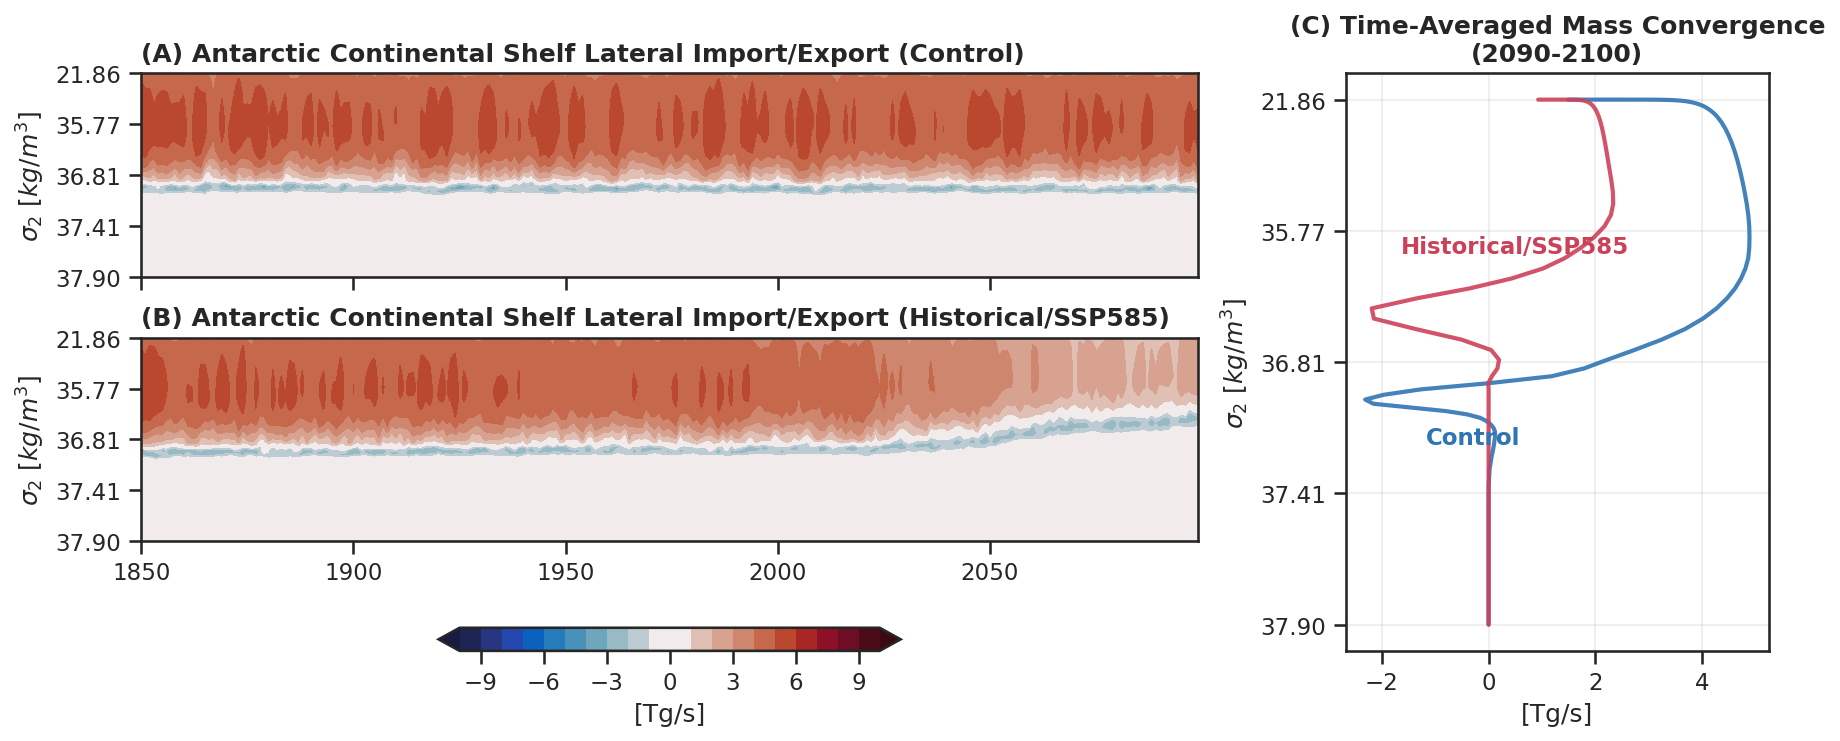

In [7]:
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.4], wspace=0.2, hspace=0.3)

# Left column: two stacked contour plots
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

# Right column: one plot spanning both rows
ax_side = fig.add_subplot(gs[:, 1])

ax = [ax0, ax1, ax_side]
ax[0].tick_params(labelbottom=False)

year = psi40_abyssal.year
density =  psi40_abyssal.sigma2_l_target
telescope_power = 10
transformed_density = density_transform(density, telescope_power)

TIME, DENS = np.meshgrid(year, transformed_density)

levels = np.arange(-10, 10 + 0.1, 1.0)
vmin = np.min(levels); vmax = np.max(levels)
cmap = extend_center_color(cmo.balance, vmin, vmax, center_min=-1, center_max=1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

ax[0].contourf(TIME,DENS, 
               toTg * psi40_abyssal.sel(exp = "control").T, 
               levels = levels, extend = "both", cmap = cmap)

cm = ax[1].contourf(TIME,DENS, 
               toTg * psi40_abyssal.sel(exp = "forced").T, 
               levels = levels, extend = "both", cmap = cmap)

fig.colorbar(cm, ax = ax[0:2], orientation = "horizontal", fraction = 0.04, label = "[Tg/s]")

# fig.suptitle("", x = 0.4)
ax[0].set_title("(A) Antarctic Continental Shelf Lateral Import/Export (Control)", loc='left', fontweight = "bold")
ax[1].set_title("(B) Antarctic Continental Shelf Lateral Import/Export (Historical/SSP585)", loc='left', fontweight = "bold")

formatter = create_density_formatter(density, transformed_density)

for a in ax: 
    a.tick_params(bottom=True, left=True)
    a.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
    a.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    a.invert_yaxis()

psi40_abyssal_mean = psi40_abyssal.sel(year = slice(2090, 2100)).mean("year")
psi40_abyssal_mean = toTg *psi40_abyssal_mean
control_mean = psi40_abyssal_mean.sel(exp = "control"); #control_mean = control_mean.where(np.abs(control_mean) > 1e-8)
forced_mean = psi40_abyssal_mean.sel(exp = "forced"); #forced_mean = forced_mean.where(np.abs(forced_mean) > 1e-8)

ax[-1].plot(control_mean, transformed_density, c = expt_colors["control"], label = "control", alpha = .9, lw = 2)
ax[-1].plot(forced_mean, transformed_density, c = expt_colors["forced"], label = "forced", alpha = .9, lw = 2)
ax[-1].text(0.3, 0.37, 'Control', 
            color=expt_colors["control"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].text(0.4, 0.7, "Historical/SSP585",
            color=expt_colors["forced"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].set_title("(C) Time-Averaged Mass Convergence\n(2090-2100)", fontweight = "bold")
ax[-1].set_xlabel("[Tg/s]")
ax[-1].grid(alpha = 0.3)

xticks = ax1.get_yticks()
ax_side.set_yticks(xticks);
fig.savefig("plots/ASC_Psi.png", dpi = 250, bbox_inches = "tight")

## Calculating Maximum Overturning

In [10]:
mean_swmt_ds = xr.open_dataset(datadir("/model/DSW_SWMT_periods.zarr"))
mean_swmt = {
    str(k): mean_swmt_ds.sel(period=k).drop_vars("period")
    for k in mean_swmt_ds.coords["period"].values.tolist()
}

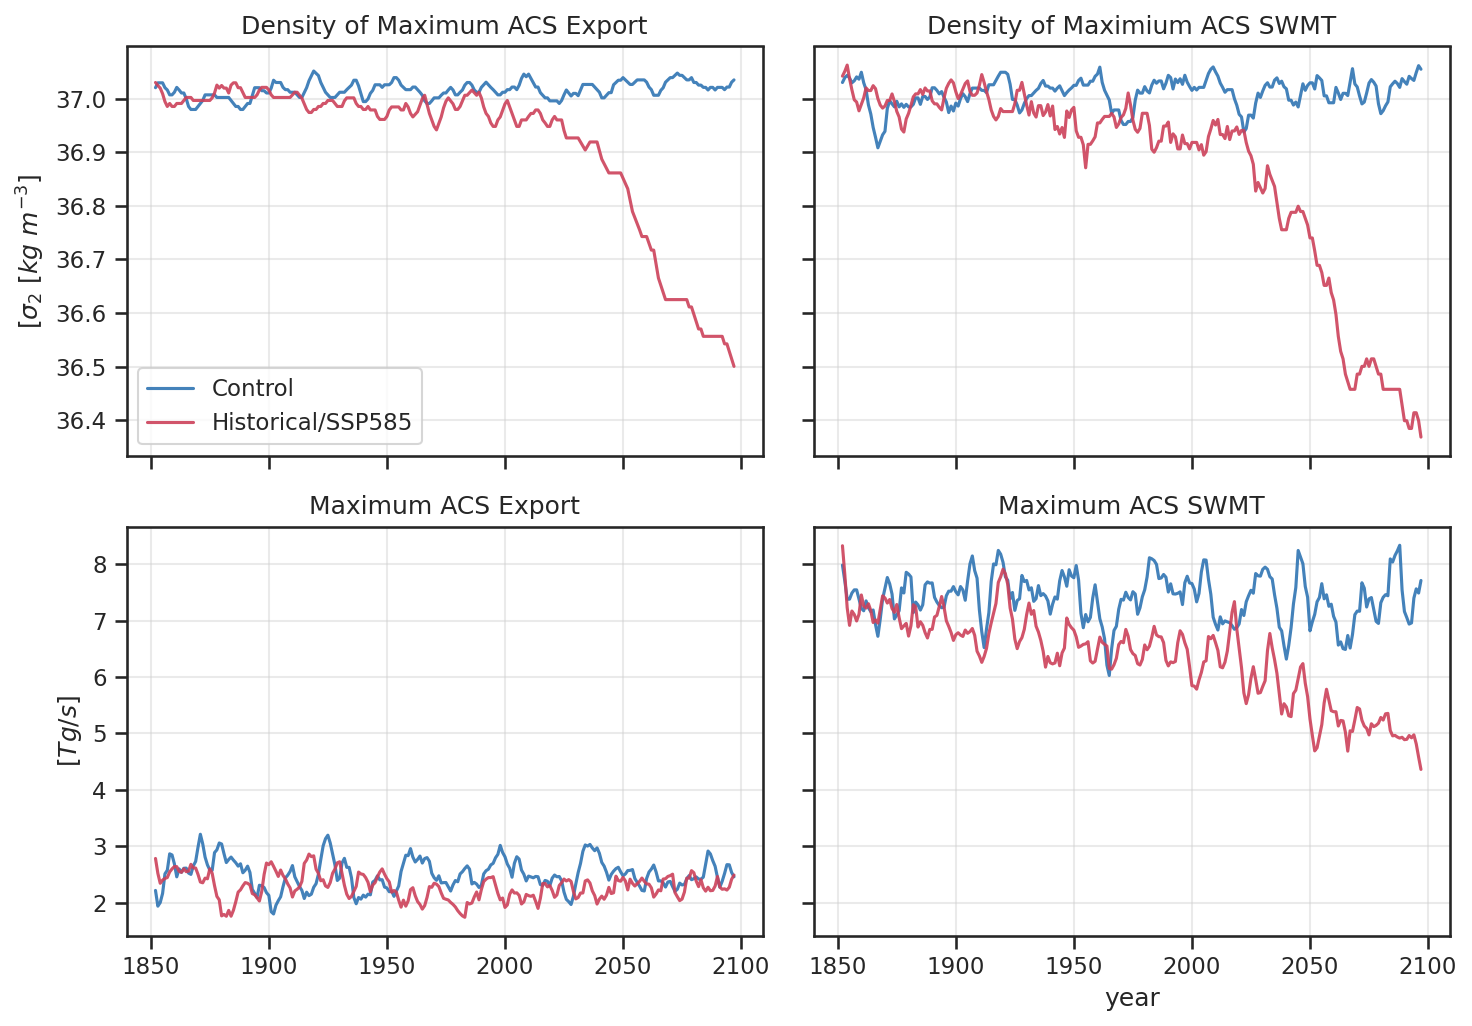

In [11]:
#PLOTTING 
year_rolling = 5
fig, ax = plt.subplots(2, 2, figsize = (10, 7), sharey = "row", sharex = True)
max_psi_loc_rolling = max_psi_loc.rolling(year=year_rolling, center=True).mean().dropna("year")
expts = ["control", "forced"]
expt_labels = ["Control", "Historical/SSP585"]
for (i, expt) in enumerate(expts):
    max_psi_loc_rolling.sel(exp =expt).plot(ax = ax[0, 0], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[0, 0].legend()
ax[0, 0].set_ylabel(r"[$\sigma_2 \ [kg\ m^{-3}$]")
ax[0, 0].set_title("Density of Maximum ACS Export")
ax[0, 0].grid(zorder = 0, alpha = 0.4)
ax[0, 0].set_xlabel("")

max_sbf_loc_rolling = max_sbf_loc.rolling(year=year_rolling, center=True).mean().dropna("year")
expts = ["control", "forced"]
expt_labels = ["Control", "Historical/SSP585"]
for (i, expt) in enumerate(expts):
    max_sbf_loc_rolling.sel(exp =expt).plot(ax = ax[0, 1], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[0, 1].set_ylabel(r"")
ax[0, 1].set_title("Density of Maximium ACS SWMT")
ax[0, 1].grid(zorder = 0, alpha = 0.4)
ax[0, 1].set_xlabel("")

max_psi_rolling = -toTg * max_psi.rolling(year=year_rolling, center=True).mean().dropna("year")
for (i, expt) in enumerate(expts):
    max_psi_rolling.sel(exp =expt).plot(ax = ax[1, 0], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[1, 0].set_ylabel(r"$[Tg/s]$")
ax[1, 0].grid(zorder = 0, alpha = 0.4)
ax[1, 0].set_xlabel("")

ax[1, 0].set_title("Maximum ACS Export" )

max_sbf_rolling = toTg * max_sbf.rolling(year=year_rolling, center=True).mean().dropna("year")
for (i, expt) in enumerate(expts):
    max_sbf_rolling.sel(exp =expt).plot(ax = ax[1, 1], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[1, 1].set_ylabel(r"")
ax[1, 1].grid(zorder = 0, alpha = 0.4)

ax[1, 1].set_title("Maximum ACS SWMT")

fig.tight_layout()

In [16]:
max_sbf_and_psi = xr.merge([max_psi, max_psi_loc, max_sbf_loc, max_sbf], compat='override')

max_sbf_and_psi["surface_boundary_fluxes"].attrs = {"units":"Tg/s"}
max_sbf_and_psi["convergent_mass_transport"].attrs = {"units":"Tg/s"}

max_sbf_and_psi.to_zarr(savedir + "Southern_Ocean_DSW_1000m_max_WMT.zarr", mode = "w")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Making a budget for a lagrangrian density class

In [17]:
sigma_mean = max_sbf_loc.sel(exp = "control").mean("year")
sigma_nearest = ds.sigma2_l_target.sel(sigma2_l_target = sigma_mean, method = "nearest")

In [18]:
toTg = 1e-9 
mass_flux_units = "Tg/s"
mass_flux_units_conversion = toTg #kg to Tg 
sigma = np.round(sigma_nearest.values, decimals = 3)
# sigma = 36.974
# tendencies = mass_flux_units_conversion * ds.sel(sigma2_l_target = sigma, method = "nearest").compute()

tendencies = mass_flux_units_conversion * select_from_location(ds_yearly, max_sbf_loc)

# tendencies = tendencies.groupby("time.year").mean("time")
tendencies = tendencies.sel(year = slice("1850", None))

In [19]:
budgets = ['mass_tendency', 
           'surface_boundary_fluxes',
           # 'surface_ocean_flux_advective_negative_rhs_salt',
           'diffusion', 
           'spurious_numerical_mixing',
           'convergent_mass_transport', 
           # "bottom_flux_heat", #this term is basically zero 
           ]

budgets_labels = ["Mass\nTendency", 
                  # r"$\mathcal{G}^{SFC, \theta}_\geq$",
                  # r"$\mathcal{G}^{SFC, FW}_\geq$",
                  "SWMT",
                  "Diffusion",
                  "Numerical\nMixing",
                  "Lateral Import/\nExport", 
                  # r"$\mathcal{G}^{\theta_{BOT}}_\geq$", 
                  ]



0.1581902818317717
-0.5921559568346775


/tmp/ipykernel_197977/573517549.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncols = 2, bbox_to_anchor = (-0.3, -0.2), frameon = False)


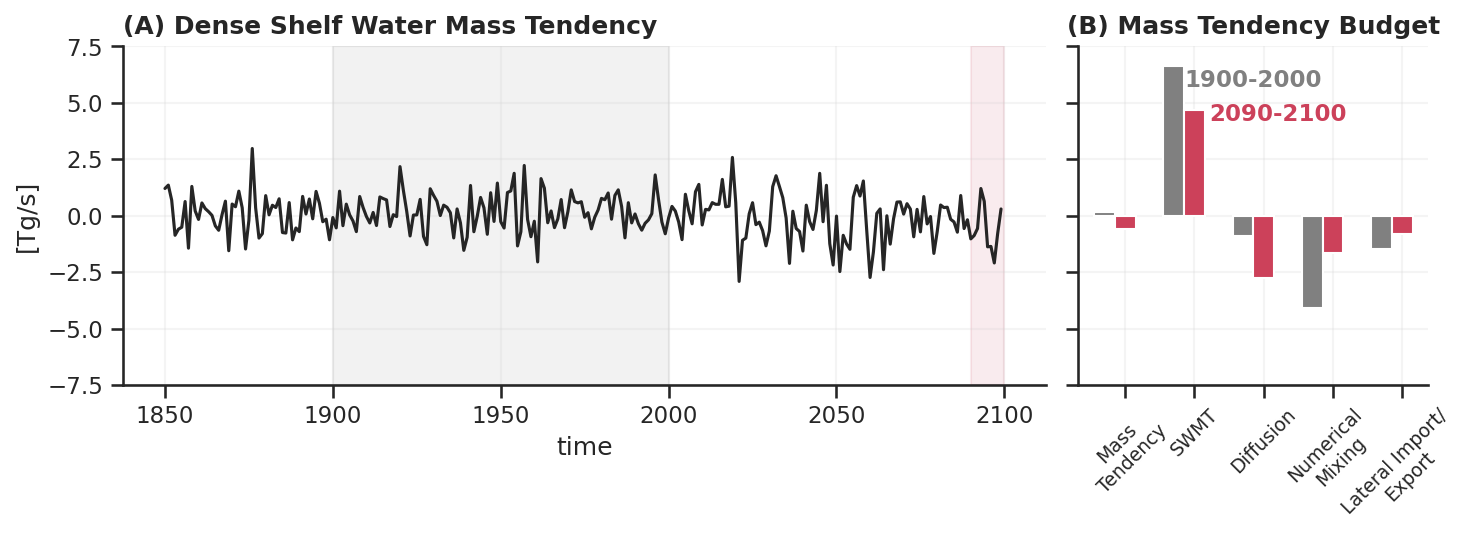

In [20]:
times2tuple= lambda s: tuple(map(int,s))

times = [("1900", "2000"), ("2090", "2100")]

reference_focus_time = times2tuple(times[0])
proj_focus_time = times2tuple(times[1])

# Create a figure
fig = plt.figure(figsize=(10, 4))

# Create a GridSpec with 4 columns, where the first plot takes up 3/4 and the second takes 1/4
gs = gridspec.GridSpec(1, 7)
# gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.4], wspace=0.2, hspace=0.3)
###### PLOT 1. TIME SERIES ###########
ax1 = fig.add_subplot(gs[0, :5])
ax = ax1
ax.grid(alpha = 0.4, axis = "y")
width = 0.3

ax.grid(alpha = 0.2)

# ax.plot(tendencies.year, tendencies["mass_tendency"].sel(exp = "control"), 
#         label = "CM4Xp125\nforced", linewidth = 1.5, alpha = 0.95, c = expt_colors["control"])
ax.plot(tendencies.year, tendencies["mass_tendency"].sel(exp = "forced"), linewidth = 1.5, alpha = 0.95, c = "k")
ax.set_ylabel(f"[{mass_flux_units}]")

ax.set_title("(A) Dense Shelf Water Mass Tendency", fontweight = "bold", loc='left')
ax.set_xlabel("time")
ax.tick_params(bottom=True, left=True)

ax.axvspan(reference_focus_time[0], reference_focus_time[1], color='grey' , alpha=0.1, zorder = 0)
ax.axvspan(proj_focus_time[0], proj_focus_time[1], color=expt_colors["forced"], alpha=0.1, zorder = 0)


###### PLOT 2. BAR PLOT ###########
ax2 = fig.add_subplot(gs[0, 5:], sharey = ax1)
ax = ax2
exp = "forced"
curr_width = 0.0
times_colors = ["grey", expt_colors["forced"]]
for (it, t) in enumerate(times):
    wmt_mean = mass_flux_units_conversion * select_from_location(ds.groupby("time.year").mean("time"), max_sbf_loc) #ds.sel(sigma2_l_target = sigma, method = "nearest")
    wmt_mean = wmt_mean.sel(year = slice(t[0], t[1])).mean("year")
    wmt_mean_budget =  wmt_mean.sel(exp = exp)
    print(wmt_mean_budget['mass_tendency'].values)
    bvalues = [wmt_mean_budget[k].values for k in budgets]

    nterms = np.arange(len(budgets_labels))

    ax.bar(nterms + curr_width, bvalues,  width = width, color = times_colors[it])
    curr_width += width
    
ax.text(0.5, 0.9, "-".join(times[0]), 
            color=times_colors[0], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)

ax.text(0.57, 0.8, "-".join(times[1]),
            color=times_colors[1], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)
    
ax.grid(alpha = 0.2)
ax.set_xticks(np.arange(len(budgets_labels)) + width, budgets_labels, rotation = 45)
ax.set_title("(B) Mass Tendency Budget", fontweight = "bold")
# ax.set_ylabel(f"[{mass_flux_units}]")
fig.tight_layout()
ax.tick_params(axis="x", labelsize=9)  # change fontsize of xticklabels
ax.legend(ncols = 2, bbox_to_anchor = (-0.3, -0.2), frameon = False)
ax.tick_params(bottom=True, left=True, labelleft=False)
fig.subplots_adjust(wspace = 0.2)
[a.set_ylim(-7.5, 7.5) for a in [ax1, ax2]]
# fig.savefig(plotsdir(f"paper_figures/dMdt_sigma_{sigma}.png"), bbox_inches = "tight", dpi = dpi)

for a in [ax1, ax2]:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

fig.savefig("plots/DSW_Mass_Tendency_Budget.png", dpi = 250, bbox_inches = "tight")

In [21]:
SWMT_var_to_label = {
    # heat budget
    "SWMT":             "net surface transformation",

    "SWMT_heat":             "heat",
    "SWMT_heat_latent":      "latent heat",
    "SWMT_heat_frazil":      "frazil",
    "SWMT_heat_longwave":    "longwave",
    "SWMT_heat_shortwave":   "shortwave heat",
    "SWMT_heat_mass_transfer":"mass transfer",
    "SWMT_heat_sensible":    "sensible heat",
    "SWMT_salt_residual":    "salt residual",
    "SWMT_residual":    "residual",

    # salt budget
    "SWMT_salt":             "salt",
    "SWMT_salt_evaporation": "evap",
    "SWMT_salt_precipitation":"precip",
    "SWMT_salt_rivers":      "rivers",
    "SWMT_salt_icebergs":    "icebergs",
    "SWMT_salt_basal_salt":  "basal salt",
    "SWMT_salt_sea_ice":     "sea-ice freeze/melt",
    "SWMT_heat_residual":    "heat residual",
    "SWMT_salt_precip_minus_evaporation": "precip/evap",
    "other_terms": "other terms"

}

In [22]:
tendencies_SWMT =  get_SWMT(tendencies)

exclude_vars = {"boundary_fluxes_heat", "SWMT", "SWMT_salt_approx", "SWMT_heat_approx", "SWMT_heat", "SWMT_salt"}
SWMT_decomp_vars = set(tendencies_SWMT.data_vars) - exclude_vars

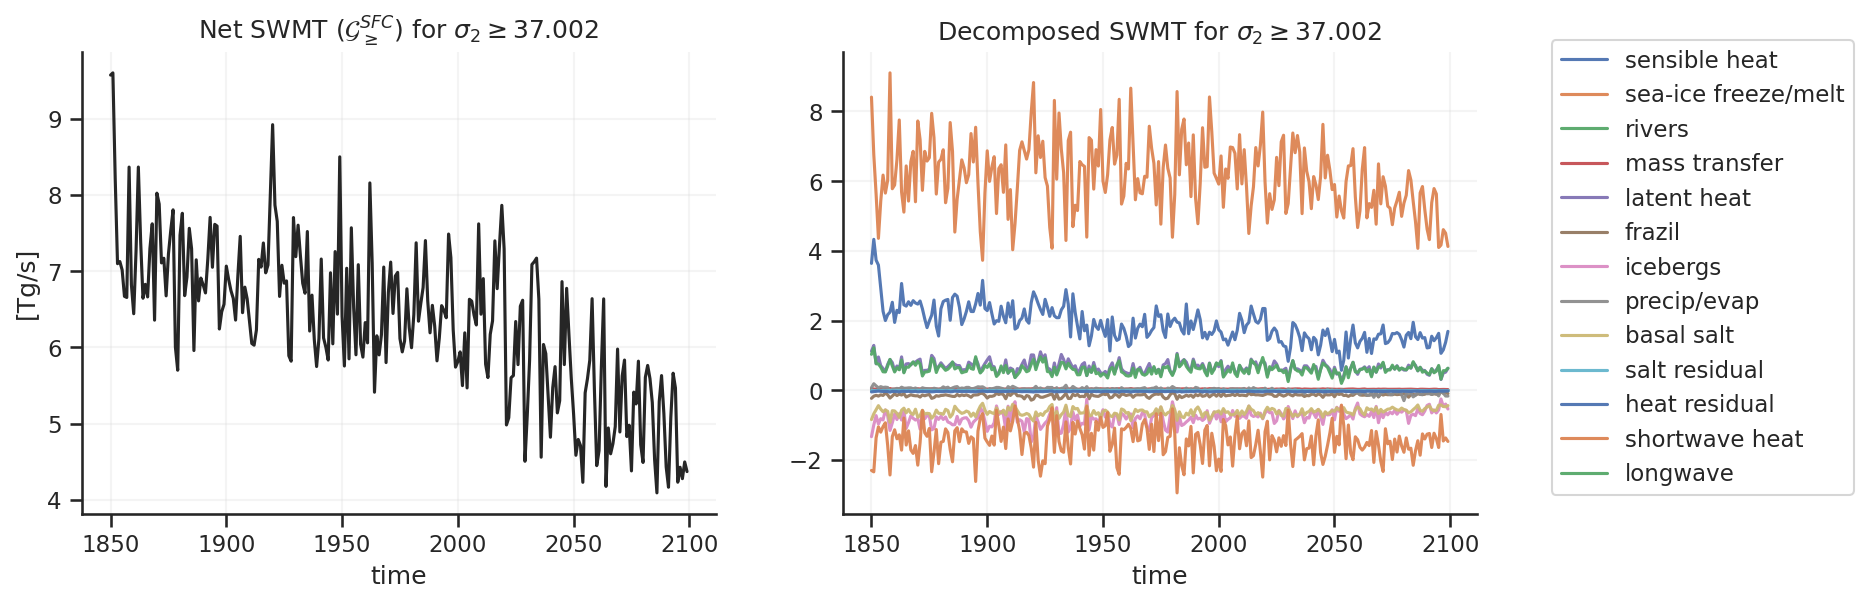

In [23]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]

ax.plot(tendencies_SWMT.year, tendencies_SWMT["SWMT"].sel(exp = "forced"), 
        label = "CM4Xp125\nforced", linewidth = 1.5, alpha = 0.95, c = "k")
ax.set_ylabel(f"[{mass_flux_units}]")

ax.set_title("Net SWMT " + r"($\mathcal{G}^{SFC}_\geq$)" + " for " + r"$\sigma_2 \geq$" +  f"{sigma}")
ax.set_xlabel("time")

ax = axes[1]
ax.set_title("Decomposed SWMT for " + r"$\sigma_2 \geq$" +  f"{sigma}")
ax.set_xlabel("time")
for var in SWMT_decomp_vars: 
    ax.plot(tendencies_SWMT.year, tendencies_SWMT[var].sel(exp = "forced"), 
        label = SWMT_var_to_label[var], linewidth = 1.5, alpha = 0.95)
ax.legend(bbox_to_anchor = (1.1, 1.05))
for a in axes: 
    a.grid(alpha = 0.2)
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

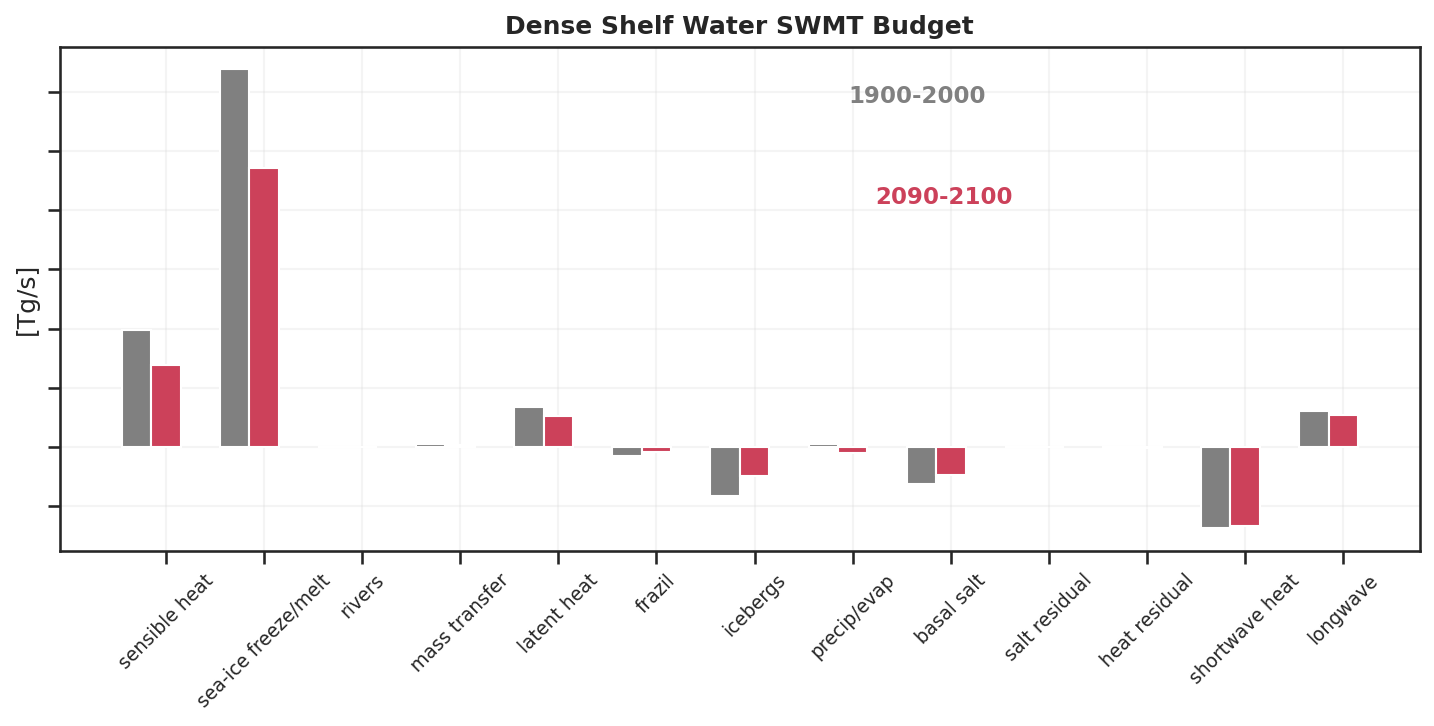

In [24]:
###### PLOT 2. BAR PLOT ###########
fig, ax = plt.subplots(figsize = (10, 5))
exp = "forced"
curr_width = 0.0
times_colors = ["grey", expt_colors["forced"]]
bvaluess = []

for (it, t) in enumerate(times):
    wmt_mean = tendencies_SWMT
    wmt_mean = wmt_mean.sel(year = slice(t[0], t[1])).mean("year")
    wmt_mean_budget =  wmt_mean.sel(exp = exp)
    bvalues = [wmt_mean_budget[k].values for k in SWMT_decomp_vars]
    bvaluess += [bvalues]

    nterms = np.arange(len(SWMT_decomp_vars))

    ax.bar(nterms + curr_width, bvalues,  width = width, color = times_colors[it])
    curr_width += width
    
ax.grid(alpha = 0.2)
labs = [SWMT_var_to_label[var] for var in SWMT_decomp_vars]
ax.set_xticks(np.arange(len(SWMT_decomp_vars)) + width, labs, rotation = 45, fontsize = 9)
ax.set_title("Dense Shelf Water SWMT Budget", fontweight = "bold")
ax.text(0.63, 0.9, "-".join(times[0]), 
            color=times_colors[0], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)

ax.text(0.65, 0.7, "-".join(times[1]),
            color=times_colors[1], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)

ax.set_ylabel(f"[{mass_flux_units}]")
fig.tight_layout()
# ax.legend(ncols = 2, bbox_to_anchor = (-0.3, -0.2), frameon = False)
ax.tick_params(bottom=True, left=True, labelleft=False)
fig.savefig("plots/DSW_SWMT_Agg_Budget.png", dpi = 250, bbox_inches = "tight")

In [25]:
100 * np.abs(np.array(bvaluess[1]) - np.array(bvaluess[0])) / np.abs(np.array(bvaluess[0]))

array([ 29.6919035 ,  26.07049124, 170.24997173,  28.2508599 ,
        21.88294594,  45.24515285,  41.41456817, 359.90257878,
        24.28511944, 189.16699761,  27.16431222,   3.04863282,
         9.78372663])

In [26]:
tendencies_SWMT_subset = tendencies_SWMT[["SWMT", "SWMT_salt_sea_ice", "SWMT_heat_sensible", "SWMT_heat_shortwave", "SWMT_heat_latent"]]
main_terms = ["SWMT_salt_sea_ice", "SWMT_heat_sensible", "SWMT_heat_shortwave", "SWMT_heat_latent"]
tendencies_SWMT_subset["other_terms"] = 1.0 * tendencies_SWMT_subset["SWMT"]
for k in main_terms:
    tendencies_SWMT_subset["other_terms"] -= tendencies_SWMT_subset[k]

main_terms += ["other_terms"]

main_terms_labels = [SWMT_var_to_label[k].replace(' ',"\n") for k in main_terms]

/tmp/ipykernel_197977/473171080.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(ncols = 2, bbox_to_anchor = (-0.3, -0.2), frameon = False)


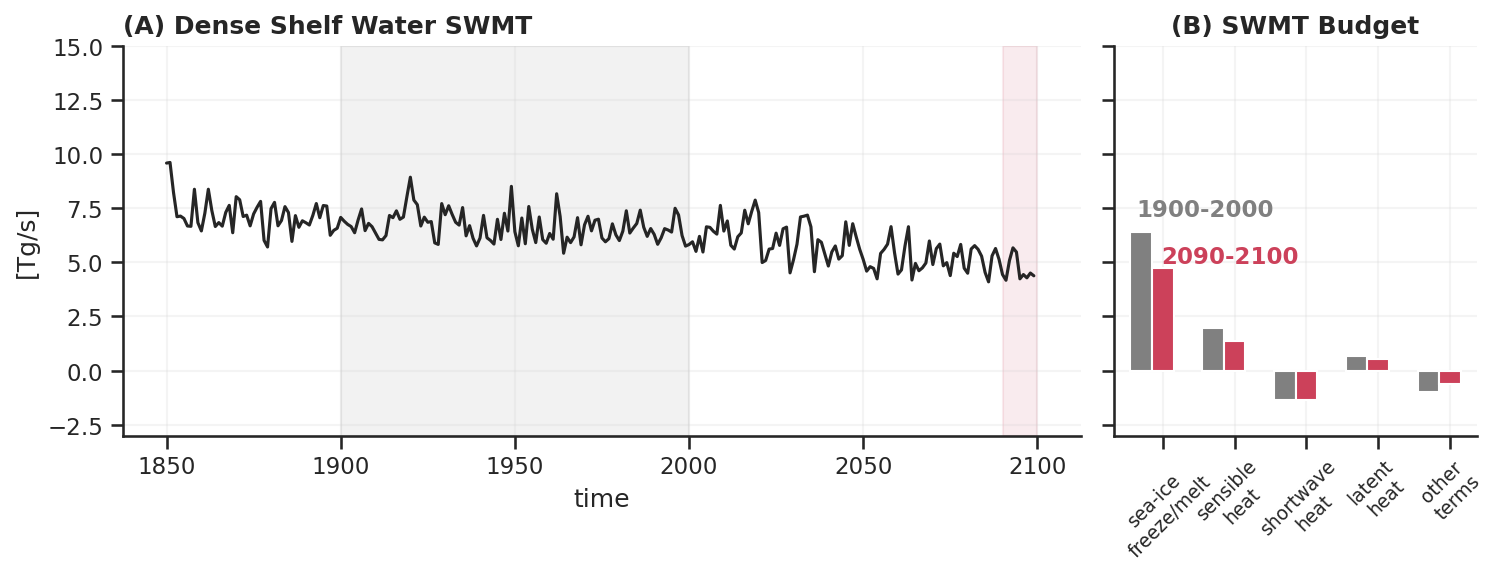

In [27]:
# Create a figure
fig = plt.figure(figsize=(10, 4))

# Create a GridSpec with 4 columns, where the first plot takes up 3/4 and the second takes 1/4
gs = gridspec.GridSpec(1, 7)

###### PLOT 1. TIME SERIES ###########
ax1 = fig.add_subplot(gs[0, :5])
ax = ax1
ax.grid(alpha = 0.4, axis = "y")
width = 0.3

ax.grid(alpha = 0.2)

# ax.plot(tendencies.year, tendencies["mass_tendency"].sel(exp = "control"), 
#         label = "CM4Xp125\nforced", linewidth = 1.5, alpha = 0.95, c = expt_colors["control"])
ax.plot(tendencies_SWMT.year, tendencies_SWMT["SWMT"].sel(exp = "forced"), 
        label = "CM4Xp125\nforced", linewidth = 1.5, alpha = 0.95, c = "k")
ax.set_ylabel(f"[{mass_flux_units}]")

ax.set_title("(A) Dense Shelf Water SWMT", fontweight = "bold", loc='left')
ax.set_xlabel("time")
ax.tick_params(bottom=True, left=True)

ax.axvspan(reference_focus_time[0], reference_focus_time[1], color='grey' , alpha=0.1, zorder = 0)
ax.axvspan(proj_focus_time[0], proj_focus_time[1], color=expt_colors["forced"], alpha=0.1, zorder = 0)

###### PLOT 2. BAR PLOT ###########
ax2 = fig.add_subplot(gs[0, 5:], sharey = ax1)
ax = ax2
exp = "forced"
curr_width = 0.0
times_colors = ["grey", expt_colors["forced"]]
bvaluess = []
for (it, t) in enumerate(times):
    wmt_mean = tendencies_SWMT_subset
    wmt_mean = wmt_mean.sel(year = slice(t[0], t[1])).mean("year")
    wmt_mean_budget =  wmt_mean.sel(exp = exp)
    bvalues = [wmt_mean_budget[k].values for k in main_terms]
    bvaluess += [bvalues]
    nterms = np.arange(len(main_terms_labels))

    ax.bar(nterms + curr_width, bvalues,  width = width, color = times_colors[it])
    curr_width += width
    
ax.grid(alpha = 0.2)
ax.set_xticks(np.arange(len(main_terms_labels)) + width, main_terms_labels, rotation = 45, fontsize = 9)
ax.set_title("(B) SWMT Budget", fontweight = "bold")
ax.text(0.25, 0.58, "-".join(times[0]), 
            color=times_colors[0], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)

ax.text(0.32, 0.46, "-".join(times[1]),
            color=times_colors[1], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)

# ax.set_ylabel(f"[{mass_flux_units}]")
fig.tight_layout()
ax.legend(ncols = 2, bbox_to_anchor = (-0.3, -0.2), frameon = False)
ax.tick_params(bottom=True, left=True, labelleft=False)
fig.subplots_adjust(wspace = 0.2)
[a.set_ylim(-3, 15) for a in [ax1, ax2]]
# fig.savefig(plotsdir(f"paper_figures/dMdt_sigma_{sigma}.png"), bbox_inches = "tight", dpi = dpi)

for a in [ax1, ax2]:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

fig.savefig("plots/DSW_SWMT_Budget.png", dpi = 250, bbox_inches = "tight")